<a href="https://colab.research.google.com/github/voirlarel/technology_ETL/blob/main/ro_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Экспериментальная матрица ошибок:
[[0.958 0.042]
 [0.046 0.954]]

Теоретическая матрица ошибок:
[[0.97589818 0.02410182]
 [0.09223314 0.90776686]]

Суммарная ошибка: теоретическая = 0.0582, экспериментальная = 0.0440, граница Чернова = 0.1354


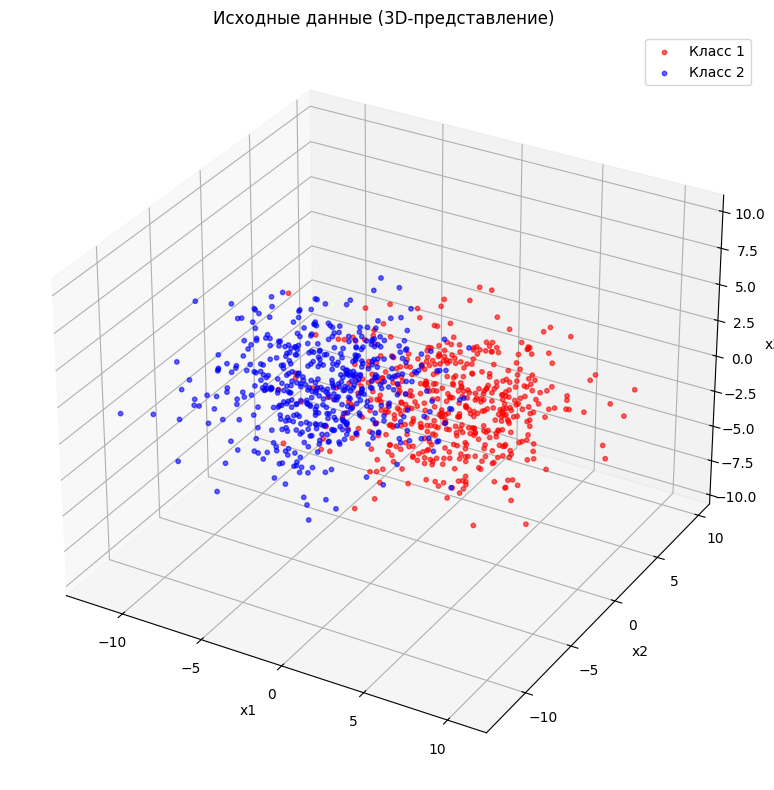

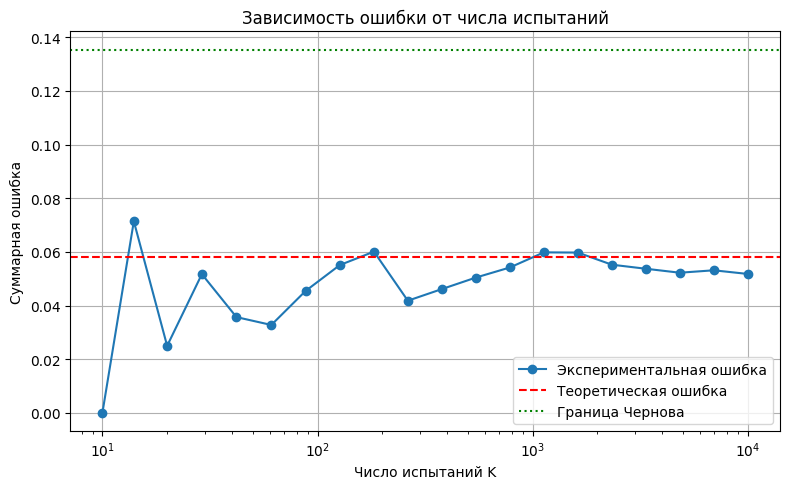

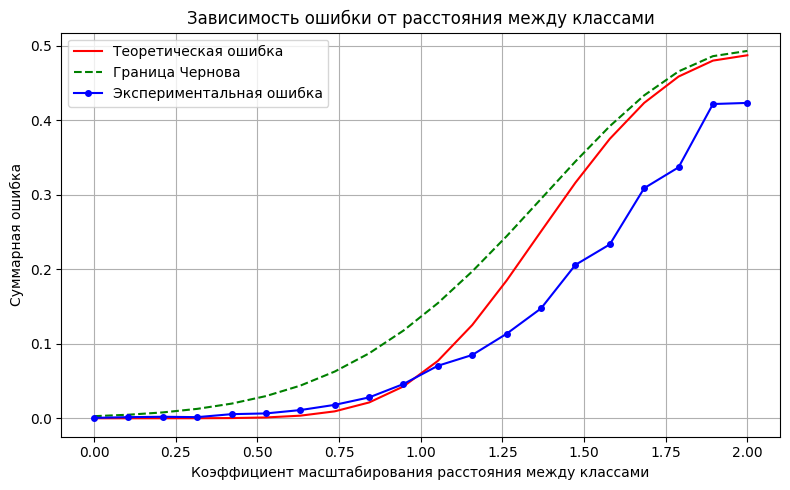

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal, norm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n = 3                       # размерность признакового пространства
M = 2                       # число классов
K = 1000                    # количество испытаний для основной оценки
pw = np.array([0.5, 0.5])   # априорные вероятности (равные)

# Математические ожидания классов
m = np.array([[1, -3],
              [2, -5],
              [-2, 2]])     # столбцы – классы

# Матрицы ковариации классов
C = np.zeros((n, n, M))
C[:, :, 0] = np.array([[12, -0.2, 1.6],
                       [-0.2, 7, -0.2],
                       [1.6, -0.2, 7]])
C[:, :, 1] = np.array([[8, 2.0, 0.7],
                       [2.0, 7, -0.5],
                       [0.7, -0.5, 7]])

# Обратные матрицы ковариации
C_inv = np.zeros_like(C)
for k in range(M):
    C_inv[:, :, k] = np.linalg.inv(C[:, :, k])

# 2. Теоретические вероятности ошибок
# Вычисление для двух классов
dm = m[:, 0] - m[:, 1]
l0 = np.log(pw[1] / pw[0])

dti = np.linalg.det(C[:, :, 0])
dtj = np.linalg.det(C[:, :, 1])

# Следы
trij = np.trace(C_inv[:, :, 1] @ C[:, :, 0] - np.eye(n))
trji = np.trace(np.eye(n) - C_inv[:, :, 0] @ C[:, :, 1])
trij_2 = np.trace(np.linalg.matrix_power(C_inv[:, :, 1] @ C[:, :, 0] - np.eye(n), 2))
trji_2 = np.trace(np.linalg.matrix_power(np.eye(n) - C_inv[:, :, 0] @ C[:, :, 1], 2))

# Параметры решающих функций
mg1 = 0.5 * (trij + dm.T @ C_inv[:, :, 0] @ dm - np.log(dti / dtj))
Dg1 = 0.5 * trij_2 + dm.T @ C_inv[:, :, 1] @ C[:, :, 0] @ C_inv[:, :, 1] @ dm
mg2 = 0.5 * (trji - dm.T @ C_inv[:, :, 1] @ dm + np.log(dtj / dti))
Dg2 = 0.5 * trji_2 + dm.T @ C_inv[:, :, 0] @ C[:, :, 1] @ C_inv[:, :, 0] @ dm
sD1 = np.sqrt(Dg1)
sD2 = np.sqrt(Dg2)

# Теоретическая матрица ошибок
PIJ = np.zeros((M, M))
PIJ[0, 1] = norm.cdf(l0, loc=mg1, scale=sD1)
PIJ[1, 0] = 1 - norm.cdf(l0, loc=mg2, scale=sD2)
PIJ[0, 0] = 1 - PIJ[0, 1]
PIJ[1, 1] = 1 - PIJ[1, 0]

# Граница Чернова (симметричная)
mu2 = (1/8) * dm.T @ np.linalg.inv((C[:, :, 0] + C[:, :, 1])/2) @ dm \
      + 0.5 * np.log((dti + dtj) / (2 * np.sqrt(dti * dtj)))
Es_chernov = np.sqrt(pw[0] * pw[1]) * np.exp(-mu2)

# 3. Статистические испытания
Pc_exp = np.zeros((M, M))          # экспериментальная матрица ошибок
for _ in range(K):
    for i in range(M):
        x = np.random.multivariate_normal(m[:, i], C[:, :, i])
        u = np.zeros(M)
        for j in range(M):
            u[j] = -0.5 * (x - m[:, j]).T @ C_inv[:, :, j] @ (x - m[:, j]) \
                   - 0.5 * np.log(np.linalg.det(C[:, :, j])) + np.log(pw[j])
        dec = np.argmax(u)
        Pc_exp[i, dec] += 1
Pc_exp /= K

# Суммарные ошибки
Es_theor = pw[0] * PIJ[0, 1] + pw[1] * PIJ[1, 0]
Es_exp   = pw[0] * Pc_exp[0, 1] + pw[1] * Pc_exp[1, 0]



print("Экспериментальная матрица ошибок:")
print(Pc_exp)
print("\nТеоретическая матрица ошибок:")
print(PIJ)
print(f"\nСуммарная ошибка: теоретическая = {Es_theor:.4f}, "
      f"экспериментальная = {Es_exp:.4f}, граница Чернова = {Es_chernov:.4f}")


# 5. Визуализация исходных данных (3D scatter)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'blue']
labels = ['Класс 1', 'Класс 2']
for i in range(M):
    # Генерируем 500 точек для каждого класса
    samples = np.random.multivariate_normal(m[:, i], C[:, :, i], 500)
    ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2],
               c=colors[i], label=labels[i], alpha=0.6, s=10)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('Исходные данные (3D-представление)')
ax.legend()
plt.tight_layout()
plt.show()


# 6. График зависимости ошибки от числа испытаний

K_list = np.logspace(1, 4, 20, dtype=int)   # от 10 до 10000
Es_exp_vs_K = []
for K_val in K_list:
    Pc_local = np.zeros((M, M))
    for _ in range(K_val):
        for i in range(M):
            x = np.random.multivariate_normal(m[:, i], C[:, :, i])
            u = np.zeros(M)
            for j in range(M):
                u[j] = -0.5 * (x - m[:, j]).T @ C_inv[:, :, j] @ (x - m[:, j]) \
                       - 0.5 * np.log(np.linalg.det(C[:, :, j])) + np.log(pw[j])
            dec = np.argmax(u)
            Pc_local[i, dec] += 1
    Pc_local /= K_val
    err = pw[0] * Pc_local[0, 1] + pw[1] * Pc_local[1, 0]
    Es_exp_vs_K.append(err)

plt.figure(figsize=(8, 5))
plt.plot(K_list, Es_exp_vs_K, 'o-', label='Экспериментальная ошибка')
plt.axhline(y=Es_theor, color='r', linestyle='--', label='Теоретическая ошибка')
plt.axhline(y=Es_chernov, color='g', linestyle=':', label='Граница Чернова')
plt.xscale('log')
plt.xlabel('Число испытаний K')
plt.ylabel('Суммарная ошибка')
plt.title('Зависимость ошибки от числа испытаний')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. График зависимости ошибки от расстояния между классами
lambdas = np.linspace(0, 2, 20)          # коэффициент масштабирования
dm_orig = m[:, 0] - m[:, 1]
Es_theor_vs_lambda = []
Es_chernov_vs_lambda = []
Es_exp_vs_lambda = []

for lam in lambdas:
    # Сдвигаем средние так, чтобы при lam=1 были исходные, при lam=0 – совпадали
    shift = (lam - 1) * dm_orig / 2
    m1_new = m[:, 0] - shift
    m2_new = m[:, 1] + shift
    dm_new = m1_new - m2_new

    # Теоретическая ошибка для новых средних
    mg1_new = 0.5 * (trij + dm_new.T @ C_inv[:, :, 0] @ dm_new - np.log(dti / dtj))
    mg2_new = 0.5 * (trji - dm_new.T @ C_inv[:, :, 1] @ dm_new + np.log(dtj / dti))
    sD1_new = np.sqrt(Dg1)
    sD2_new = np.sqrt(Dg2)
    p12_new = norm.cdf(l0, loc=mg1_new, scale=sD1_new)
    p21_new = 1 - norm.cdf(l0, loc=mg2_new, scale=sD2_new)
    err_th = pw[0] * p12_new + pw[1] * p21_new
    Es_theor_vs_lambda.append(err_th)

    # Граница Чернова
    mu2_new = (1/8) * dm_new.T @ np.linalg.inv((C[:, :, 0] + C[:, :, 1])/2) @ dm_new \
              + 0.5 * np.log((dti + dtj) / (2 * np.sqrt(dti * dtj)))
    err_ch = np.sqrt(pw[0] * pw[1]) * np.exp(-mu2_new)
    Es_chernov_vs_lambda.append(err_ch)

    # Экспериментальная ошибка для новых средних
    Pc_local = np.zeros((M, M))
    for _ in range(K):
        for i in range(M):
            mean_i = m1_new if i == 0 else m2_new
            x = np.random.multivariate_normal(mean_i, C[:, :, i])
            u = np.zeros(M)
            for j in range(M):
                mean_j = m1_new if j == 0 else m2_new
                u[j] = -0.5 * (x - mean_j).T @ C_inv[:, :, j] @ (x - mean_j) \
                       - 0.5 * np.log(np.linalg.det(C[:, :, j])) + np.log(pw[j])
            dec = np.argmax(u)
            Pc_local[i, dec] += 1
    Pc_local /= K
    err_exp = pw[0] * Pc_local[0, 1] + pw[1] * Pc_local[1, 0]
    Es_exp_vs_lambda.append(err_exp)

plt.figure(figsize=(8, 5))
plt.plot(lambdas, Es_theor_vs_lambda, 'r-', label='Теоретическая ошибка')
plt.plot(lambdas, Es_chernov_vs_lambda, 'g--', label='Граница Чернова')
plt.plot(lambdas, Es_exp_vs_lambda, 'bo-', label='Экспериментальная ошибка', markersize=4)
plt.xlabel('Коэффициент масштабирования расстояния между классами')
plt.ylabel('Суммарная ошибка')
plt.title('Зависимость ошибки от расстояния между классами')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()